# Lab 2 Ghofran's code

In [1]:
#####################################
### Import the relevant libraries ###
#####################################
import random # to set random seed for reproducibility
# numpy and pandas: handle data and numerical operations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # used for all the plots (accuracy/loss curves, confusion matrix, etc.)

from sklearn.model_selection import train_test_split # to split the dataset into training and testing sets
# converts text data into numerical vectors (TF-IDF = Term Frequency–Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler # rescales numbers between 0 and 1 (important for PGD and neural networks)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # to evaluate the model's performance
from sklearn.utils.class_weight import compute_class_weight # to handle class imbalance by assigning weights to classes
from sklearn.decomposition import PCA # to reduce dimensionality of TF-IDF vectors for visualization
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap


# TensorFlow and Keras: import, build, and train the neural networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model # layers to build the neural network


In [2]:
########################
##### Define Seeds #####
########################
# using a fixed seed ensures that random operations (train/test splits or sampling) produce the same results
# every time we run the notebook, making experiments repeatablem.
SEED = 42 # any integer works, 4 is arbitrary
np.random.seed(SEED) # set numpy random seed
tf.random.set_seed(SEED) # set TensorFlow random seed
random.seed(SEED) # set Python random seed

In [3]:
####################################
##### Load the cleaned dataset #####
####################################
'''DATA_PATH = "cleaned_medicheck-expert.csv" # path to the cleaned dataset
Dset = pd.read_csv(DATA_PATH) # loads cleaned dataset into a DataFrame.
print("Shape:", Dset.shape) # show the shape of the Dataset (rows, columns)
print(Dset.head(3)) # show the first 3 rows of the dataset'''

# Paths to both datasets
EXPERT_PATH = "cleaned_medicheck-expert.csv"   # labelled expert file
NEG_PATH    = "medicheck-neg.csv"              # unlabelled negative file

# Load the expert (medical) dataset
expert_df = pd.read_csv(EXPERT_PATH)
print("Expert dataset:", expert_df.shape)
print(expert_df.head(3)) # show the first 3 rows of the dataset

# Load the negative (non-medical) dataset
neg_df = pd.read_csv(NEG_PATH)
print("Negative dataset:", neg_df.shape)
print(neg_df.head(3)) # show the first 3 rows of the dataset

Expert dataset: (1416, 2)
                                               query  query-label-expert
0  Why do i get a bad headache when i don't eat e...                   2
1  What causes heart rate to suddenly quicken to ...                   2
2  peritonsillar abscess drainage aftercare.. ple...                   2
Negative dataset: (1499, 1)
                                               query
0  If ingesting salt causes dehydration and dehyd...
1      What's the worst thing you did as a teenager?
2                       What is your biggest regret?


In [4]:
##############################################
### Relabel to binary according to ANTONIO ###
##############################################
# Antonio's relabeling scheme: 1,2,3 -> medical (0); 0 -> non-medical (1); else NaN
def antonio_relabel(x):
    if x in [1, 2, 3]:   # any medical seriousness level
        return 0         # medical
    elif x == 0:
        return 1         # non-medical
    else:
        return np.nan

# Apply the relabeling function and clean the dataframe
# Keep only the relevant columns: "query" (text) and "query-label-expert" (label).
expert_df = expert_df[["query", "query-label-expert"]].copy()
expert_df["label"] = expert_df["query-label-expert"].apply(antonio_relabel) # Apply the relabel function to create a new column "label".
expert_df = expert_df.dropna(subset=["label"]) # Drop rows where "label" is NaN (missing labels).
expert_df["label"] = expert_df["label"].astype(int) # Convert labels to integers (0 and 1).
# Clean the text:
    # astype(str) → ensure all entries are strings.
    # str.replace(r"\s+"," ", regex=True) → replace multiple spaces/tabs with a single space.
    # str.strip() → remove leading/trailing spaces.
expert_df["query"] = expert_df["query"].astype(str).str.replace(r"\s+"," ", regex=True).str.strip()

# Shows how many 0s (medical) and 1s (non-medical) after relabelling in expert dataset
print("Label distribution (ANTONIO):\n", expert_df["label"].value_counts())
expert_df.head(5) # show the first 5 rows of the updated dataset

Label distribution (ANTONIO):
 label
0    1412
1       4
Name: count, dtype: int64


,query,query-label-expert,label
0,Why do i get a bad headache when i don't eat e...,2,0
1,What causes heart rate to suddenly quicken to ...,2,0
2,peritonsillar abscess drainage aftercare.. ple...,2,0
3,How serious is Mono or tonsillitis when untrea...,2,0
4,What are your chances of dying in your sleep?,1,0


In [5]:
# Step 4 — Label the negative dataset
# For neg_df: all entries are non-medical → label 1
neg_df = neg_df[["query"]].copy()
neg_df["query"] = neg_df["query"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
neg_df["label"] = 1

print("Negative dataset sample:\n", neg_df.head(3))
print("Negative dataset size:", len(neg_df))

Negative dataset sample:
                                                query  label
0  If ingesting salt causes dehydration and dehyd...      1
1      What's the worst thing you did as a teenager?      1
2                       What is your biggest regret?      1
Negative dataset size: 1499


In [6]:
# Step 5 — Combine both datasets
# Concatenate expert and negative queries together
combined_df = pd.concat([expert_df[["query", "label"]], neg_df], ignore_index=True)

# Shuffle to mix medical / non-medical examples
combined_df = combined_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Combined dataset size:", combined_df.shape)
print(combined_df["label"].value_counts())
combined_df.head(8)

# Step 6 — Save and check
combined_df.to_csv("combined_medicheck_dataset.csv", index=False)
print("Saved combined dataset as combined_medicheck_dataset.csv")

Combined dataset size: (2915, 2)
label
1    1503
0    1412
Name: count, dtype: int64
Saved combined dataset as combined_medicheck_dataset.csv


In [7]:
#####################
### Show Examples ###
#####################
# Show a few examples from each class by picking 5 random queries from each class (0 and 1).
print("\nMedical (label 0) examples:")
for q in combined_df[combined_df.label==0].sample(min(5, (combined_df.label==0).sum()), random_state=SEED)["query"].tolist():
    print(q)
print("\nNon-medical (label 1) examples:")
for q in combined_df[combined_df.label==1].sample(min(5, (combined_df.label==1).sum()), random_state=SEED)["query"].tolist():
    print(q)


Medical (label 0) examples:
I have had 7 CT scans and I'm 30 years old. What is my cancer risk?!
Theoretical Question for a pt with C3/C4 SCI Autonomic Dysreflexia. Why can the PSNS lower the HR, but not dilate the vessels below the SCI?
Recovered from Stomach Flu, but eating is still tough... what do?
Left leg is swelling, doctor can't figure out why
What can cause this variety of symptoms?

Non-medical (label 1) examples:
Has there ever been an NFC or AFC championship where the two wildcard teams faced each other?
What's a lie you told as a kid, but never got around to confessing?
What food tastes better with sauce?
Day 6 or What Happens to Your Body on Keto
You know those stories where everyone gradually forgets about someone close to them to the point where that person vanishes from existence?


In [8]:
############################################
###### Split data into train and test ######
############################################
X = combined_df["query"].values  # X = all query texts.
y = combined_df["label"].values  # y = corresponding binary labels (0=medical, 1=non-medical).

# train_test_split divides the dataset into:70% for training (X_train_text, y_train) 30% for testing (X_test_text, y_test)
X_train_text, X_test_text, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=SEED, stratify=y)  # stratify=y keeps the same label distribution in train and test sets

print("Train size:", len(X_train_text), " Test size:", len(X_test_text)) # show the sizes of train and test sets
print("Train label counts:", np.bincount(y_train))  # show the label distribution in the training set
print("Test  label counts:", np.bincount(y_test))   # show the label distribution in the test set

Train size: 2040  Test size: 875
Train label counts: [ 988 1052]
Test  label counts: [424 451]


In [9]:
##########################################################################
### Turn text into numerical features >> Vectorizing the text (TF-IDF) ###
##########################################################################
# Vectorization (TF-IDF -> dense -> scaled to [0,1] for stable PGD)
# TF-IDF counts how important each word or word-pair (bigram) is for distinguishing between classes.
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000) # max_features keeps the top 5000 most frequent features
# Learn vocabulary from training set and transform both sets
X_train_tfidf = vectorizer.fit_transform(X_train_text)   # learn vocabulary from train data, then apply to training text
X_test_tfidf  = vectorizer.transform(X_test_text)   # apply the same train vocabulary to the test text.

# Converts sparse TF-IDF matrices into dense matrices for Keras + PGD (Keras expects dense inputs).
    # A dense array/matrix is a regular NumPy array where all values are stored explicitly in memory.
    # A sparse array only stores nonzero values and their positions, saving memory when most values are zero.
    # Machine learning libraries like Keras require dense arrays as input,
    # so sparse matrices (like those from TF-IDF vectorization) are converted to dense arrays before training.
X_train_dense = X_train_tfidf.toarray().astype("float32")
X_test_dense  = X_test_tfidf.toarray().astype("float32")

# Scales each feature to the range [0, 1] for better numerical stability during training and adversarial attacks.
scaler = MinMaxScaler() # scales each feature to [0,1]
X_train = scaler.fit_transform(X_train_dense).astype("float32") # fit scaler on train, apply to train
X_test  = scaler.transform(X_test_dense).astype("float32")  # apply same scaler to test

X_train.shape, X_test.shape # check the shape of the final input matrices

((2040, 5000), (875, 5000))

In [10]:
# Optional: compute class weights (helps if non-medical is rare)
# why? if dataset has far more medical (0) than non-medical (1) samples,
# the model could “cheat” by always predicting 0.
classes = np.unique(y_train) # find all unique label values in y_train (should be [0, 1])

# compute_class_weight: calculates a weight for each class so that rare classes are not ignored.
# class_weight="balanced": automatically gives a higher weight to the minority class.
# classes=classes: the list of unique class labels.
# y=y_train: the labels from the training set.
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

# This line creates a dictionary mapping each class label (int(c)) to its computed weight (float(w)).
# The dictionary class_weight_dict tells Keras how to re-balance loss contributions.
# zip(classes, class_weights): pairs each class with its corresponding weight.
class_weight_dict_auto = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Automatic Class weights:", class_weight_dict_auto) # show the auto computed class weights
# Another way: give more weight to class 0 because we care more about detecting medical queries correctly
# Manually assign weights, avoid making it too extreme (like 10×), or the model may misclassify everything as medical
class_weight_dict_manu = {0: 3.0, 1: 1.0}   # medical (0) is 3× more important
print("Manual class weights:", class_weight_dict_manu)


Automatic Class weights: {0: 1.0323886639676114, 1: 0.9695817490494296}
Manual class weights: {0: 3.0, 1: 1.0}


In [11]:
###############################################
### Define and train a small dense NN model ###
###############################################
def build_model(input_dim):
    model = keras.Sequential([          # Define a Sequential model (a stack of layers)
        layers.Input(shape=(input_dim,)),  # Input layer = size of TF-IDF vector
        layers.Dense(256, activation="relu"), # First fully connected hidden layer with 256 neurons and ReLU activation
        layers.Dropout(0.3),           # randomly ignores 30% of neurons during training (prevents overfitting)
        layers.Dense(64, activation="relu"), # Second fully connected hidden layer with 64 neurons and ReLU activation
        layers.Dense(1, activation="sigmoid") # Output layer = single neuron with sigmoid activation (binary classification)
    ])
    # Adam optimizer algorithm automatically adjusts learning rates during training,
    # making it efficient and popular for deep learning tasks.
    # 1e-3 = 0.001 sets the learning rate for the Adam optimizer,
    # controlling how much the model's weights are updated during training.
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",   # Loss function: binary cross-entropy (for binary classification)
                  metrics=["accuracy"])         # Metric to monitor: accuracy
    return model

model = build_model(X_train.shape[1])           # Build the model
model.summary()                                 # shows how many parameters each layer has


# Train baseline
history = model.fit(      # starts training
    X_train,              # input features for training (dense, scaled TF-IDF vectors)
    y_train,              # target labels for training (0=medical, 1=non-medical)
    validation_split=0.1, # use 10% of training data for validation (to monitor overfitting)
                          # i.e: 10 % of training data is held out to monitor performance each epoch.
    epochs=10,            # train for 10 passes (go through the entire training dataset 10 times)
    batch_size=32,        # batch_size=32: number of samples processed before updating model weights
                          # smaller batches use less memory and provide more frequent updates, but can be noisier.
                          # 32 samples per mini-batch (gradient update every 32 examples).
    verbose=1,            # verbose=1: print progress bar and training details during fitting
    # comment these two if we don't want weighting or comment one of them to test the other
    #class_weight=class_weight_dict_auto  # re-balances the classes (if they are imbalanced) using auto weight
    class_weight=class_weight_dict_manu  # give more weight to medical queries (class 0) using manual weight
)

# Save the trained model so we can reload it later (in Feature Entanglement step)
model.save("trained_model.keras")
print("Model saved successfully.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,769 (4.95 MB)

 Trainable params: 1,296,769 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4896 - loss: 1.2057 - val_accuracy: 0.5343 - val_loss: 0.6459
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6935 - loss: 0.6126 - val_accuracy: 0.8333 - val_loss: 0.3771
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9581 - loss: 0.1590 - val_accuracy: 0.8824 - val_loss: 0.3399
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9890 - loss: 0.0424 - val_accuracy: 0.8824 - val_loss: 0.3400
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9974 - loss: 0.0179 - val_accuracy: 0.8725 - val_loss: 0.3818
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9973 - loss: 0.0120 - val_accuracy: 0.8824 - val_loss: 0.3824
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9962 - loss: 0.0092 - val_accuracy: 0.8824 - val_loss: 0.3971
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9963 - loss: 0.0090 - val_accuracy: 0.8775 - v

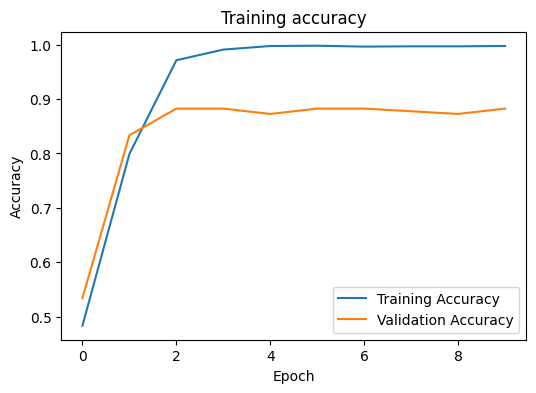

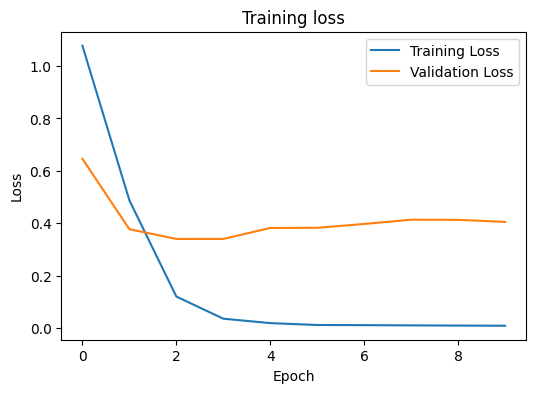

In [12]:
############################
### Plot training curves ###
############################
# Plot training accuracy
# This plot show over- or under-fitting:
    # If training accuracy goes up but validation accuracy goes down → overfitting.
    # If both low → underfitting or need more epochs.
plt.figure(figsize=(6,4))                       # Create a new figure with size 6x4 inches
plt.plot(history.history["accuracy"], label="Training Accuracy")      # Plot training accuracy per epoch
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")    # Plot validation accuracy per epoch
plt.xlabel("Epoch")                              # Label x-axis as "Epoch"
plt.ylabel("Accuracy")                           # Label y-axis as "Accuracy"
plt.legend()                                     # Show legend for the curves
plt.title("Training accuracy")                   # Set plot title
plt.show()                                       # Display the plot

# Plotting training loss
# The loss plot shows whether the optimisation is still improving.
    # If Both training and validation loss decreasing together → model is learning properly; optimisation is improving.
    # If Training loss dropping but validation loss rising → model is overfitting
     #(memorising training examples instead of learning general rules) so we might need: more data,
     # more regularisation (Dropout), or stop training earlier (use “early stopping”).
    # If both losses flat → Model stuck or learning finished
plt.figure(figsize=(6,4))                        # Create a new figure for loss curves
plt.plot(history.history["loss"], label="Training Loss")          # Plot training loss per epoch
plt.plot(history.history["val_loss"], label="Validation Loss")        # Plot validation loss per epoch
plt.xlabel("Epoch")                              # Label x-axis as "Epoch"
plt.ylabel("Loss")                               # Label y-axis as "Loss"
plt.legend()                                     # Show legend for the curves
plt.title("Training loss")                       # Set plot title
plt.show()                                       # Display the plot

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Clean accuracy: 0.824

Classification report:
               precision    recall  f1-score   support

           0      0.812     0.828     0.820       424
           1      0.835     0.820     0.828       451

    accuracy                          0.824       875
   macro avg      0.824     0.824     0.824       875
weighted avg      0.824     0.824     0.824       875



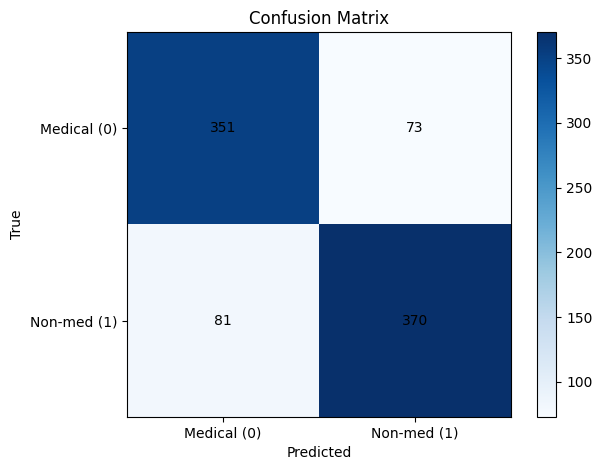

In [13]:
# Step 3H — Evaluation on clean test set
# get predicted probabilities in [0, 1] for each test sample; .ravel() flatten  Keras returned 2D array to 1D
y_prob = model.predict(X_test).ravel()
# threshold probabilities at 0.5 to get binary predictions; .astype(int) converts True/False to 1/0
y_pred = (y_prob >= 0.5).astype(int) # convert probabilities ≥ 0.5 to class 1, else 0

#Accuracy: overall correctness, computes the fraction of correct predictions
print("Clean accuracy:", accuracy_score(y_test, y_pred))
# classification_report: prints precision, recall, f1-score for each class; digits=3: round to 3 decimals
    # Precision = of predicted positives, how many were right?
    # Recall = of real positives, how many did we catch?
    # F1-score = harmonic mean of precision and recall (balances both metrics)
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

# creates a confusion matrix showing counts of true vs predicted labels
Conf_mat = confusion_matrix(y_test, y_pred)

#plt.figure(figsize=(4,3))                   # Create a new figure with size 4x3 inches
plt.imshow(Conf_mat, cmap="Blues")          # Display the confusion matrix as an image with blue color map
plt.title("Confusion Matrix")               # Set plot title
plt.colorbar()                              # Show color bar for reference
plt.xticks([0,1], ["Medical (0)", "Non-med (1)"])  # Set x-axis tick labels
plt.yticks([0,1], ["Medical (0)", "Non-med (1)"])  # Set y-axis tick labels

for i in range(2):                          # Loop over rows (true labels)
    for j in range(2):                      # Loop over columns (predicted labels)
        plt.text(j, i, Conf_mat[i, j], ha="center", va="center")  # Write the count in each cell, centered

plt.xlabel("Predicted")                     # Label x-axis
plt.ylabel("True")                          # Label y-axis
plt.tight_layout()                          # Adjust layout to fit everything
plt.show()                                  # Display the plot


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


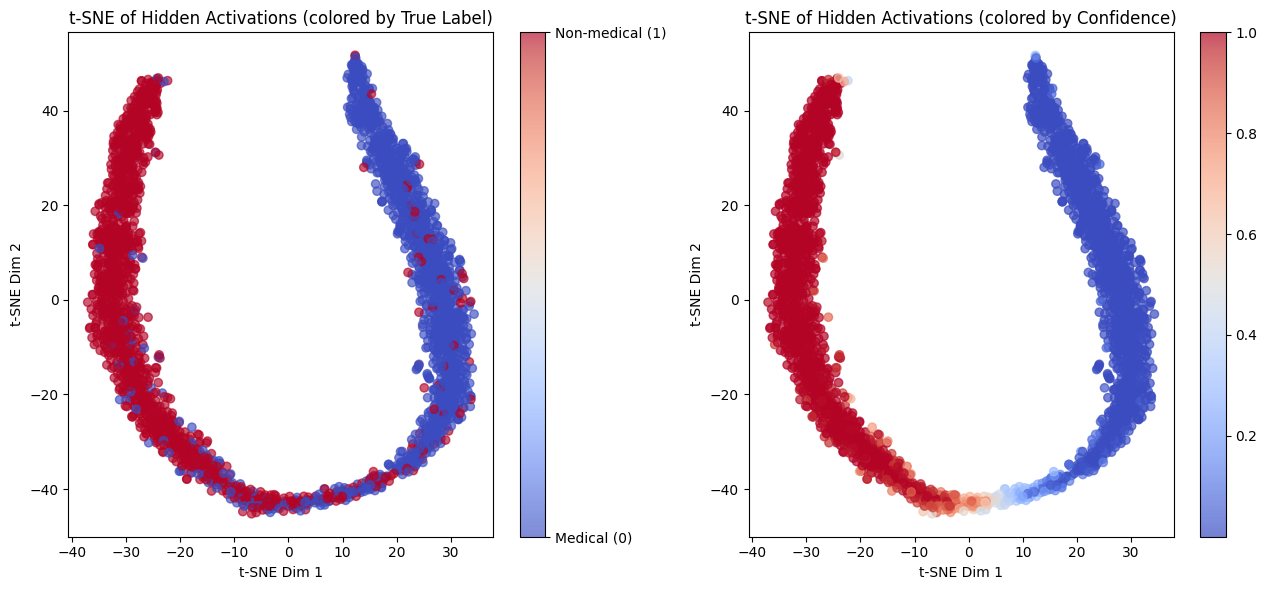

In [28]:
# Step 12 — Feature Entanglement (visualise learned features with t-SNE)

# reload the trained model
model = keras.models.load_model("trained_model.keras")

# Use all layers except the final output layer
get_hidden_output = keras.Sequential(model.layers[:-1])

# Collect data (subset for speed)
X_all = np.vstack([X_train[:5000], X_test[:5000]])
y_all = np.concatenate([y_train[:5000], y_test[:5000]])

# Extract hidden activations from the trained network
H = get_hidden_output.predict(X_all, batch_size=256)

# Scale hidden features (important for distance-based methods)
#H_std = StandardScaler().fit_transform(H)

# Use PCA before t-SNE to compress (faster convergence, denoises, & tunes t-SNE)
# initial PCA step = 50 components gives more global separation
H_pca = PCA(n_components=50, random_state=SEED).fit_transform(H)

# --- Apply t-SNE to 2D space ---
tsne = TSNE(
    n_components=2,
    perplexity=40,             # adjust between 20–50 to tune cluster tightness
    max_iter=1500,             # adjust between 1500–2000 for smoother layouts
    #early_exaggeration=24,    # adjust between 12–32
    learning_rate=200,         # or 500, 800
    metric='cosine',          # often better for text features, tunes t-SNE
    #init='pca',
    random_state=SEED
)
H2 = tsne.fit_transform(H_pca)

# --- Plot the t-SNE embedding ---
# color by model confidence in addition to class

# Predict probabilities (confidence of class 1)
probs = model.predict(X_all, batch_size=256).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (A) Plot by true labels
sc1 = axes[0].scatter(H2[:,0], H2[:,1], c=y_all, cmap="coolwarm", alpha=0.65)
axes[0].set_title("t-SNE of Hidden Activations (colored by True Label)")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")
cbar1 = plt.colorbar(sc1, ax=axes[0], ticks=[0,1])
cbar1.ax.set_yticklabels(["Medical (0)", "Non-medical (1)"])

# (B) Plot by model confidence
sc2 = axes[1].scatter(H2[:,0], H2[:,1], c=probs, cmap="coolwarm", alpha=0.7)
axes[1].set_title("t-SNE of Hidden Activations (colored by Confidence)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
cbar2 = plt.colorbar(sc2, ax=axes[1])
#cbar2.set_label("Confidence  (Non-medical → Medical)")

plt.tight_layout()
plt.show()


In [30]:
# Step 13 — PGD Attack (robustness check)
# attack the model using PGD (Projected Gradient Descent) in feature space.
def pgd_linf(model, x_np, y_np, eps=0.10, alpha=0.02, iters=10):
    """
    L∞ PGD attack on feature space.
    eps   : maximum allowed perturbation
    alpha : step size per iteration
    iters : number of iterations
    """
    x_adv = x_np.copy().astype("float32")
    y_tf = tf.convert_to_tensor(y_np.astype("float32"))
    for _ in range(iters):
        x_tf = tf.convert_to_tensor(x_adv)
        x_tf = tf.Variable(x_tf)
        with tf.GradientTape() as tape:
            logits = model(x_tf, training=False)
            logits = tf.reshape(logits, [-1])     # ensure shape (batch,)
            loss = keras.losses.binary_crossentropy(y_tf, logits)
        grad = tape.gradient(loss, x_tf).numpy()
        x_adv = x_adv + alpha * np.sign(grad) # Gradient sign step
        # Project to L∞ ball and clip to [0,1]
        x_adv = np.clip(x_adv, x_np - eps, x_np + eps)
        x_adv = np.clip(x_adv, 0.0, 1.0)
    return x_adv


# Now use it on test data and compute robust accuracy
eps, alpha, iters = 0.10, 0.02, 10
B = 256
X_test_adv = np.zeros_like(X_test)

for i in range(0, len(X_test), B):
    xb = X_test[i:i+B]
    yb = y_test[i:i+B]
    X_test_adv[i:i+len(xb)] = pgd_linf(model, xb, yb, eps=eps, alpha=alpha, iters=iters)

y_pred_clean = (model.predict(X_test).ravel() >= 0.5).astype(int)
y_pred_adv   = (model.predict(X_test_adv).ravel() >= 0.5).astype(int)

clean_acc  = accuracy_score(y_test, y_pred_clean)
robust_acc = accuracy_score(y_test, y_pred_adv)

print(f"Clean accuracy:  {clean_acc:.4f}")
print(f"Robust accuracy: {robust_acc:.4f}  (PGD eps={eps}, alpha={alpha}, iters={iters})")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Clean accuracy:  0.8240
Robust accuracy: 0.0057  (PGD eps=0.1, alpha=0.02, iters=10)


In [33]:
# Step 14 — Adversarial Training (to improve robustness)
# retrain the model on a mixture of clean + attacked samples.

subset = min(2000, len(X_train))
X_train_sub = X_train[:subset]
y_train_sub = y_train[:subset]

# Create adversarial versions of part of the training data
X_train_adv = np.zeros_like(X_train_sub)
for i in range(0, len(X_train_sub), B):
    xb = X_train_sub[i:i+B]
    yb = y_train_sub[i:i+B]
    X_train_adv[i:i+len(xb)] = pgd_linf(model, xb, yb, eps=eps, alpha=alpha, iters=iters)

# Combine clean + adversarial samples
X_comb = np.vstack([X_train, X_train_adv])
y_comb = np.concatenate([y_train, y_train_sub])

# Shuffle combined data
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(X_comb))
X_comb = X_comb[perm]; y_comb = y_comb[perm]

# train a new model on this mixed data:

model_adv = build_model(X_comb.shape[1])

history_adv = model_adv.fit(
    X_comb, y_comb,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1,
    class_weight=class_weight_dict_manu
)


# Finally, evaluate clean vs attacked performance again:

# Evaluate on clean test
y_pred_clean2 = (model_adv.predict(X_test).ravel() >= 0.5).astype(int)

# Generate adversarial test samples again
X_test_adv2 = np.zeros_like(X_test)
for i in range(0, len(X_test), B):
    xb = X_test[i:i+B]
    yb = y_test[i:i+B]
    X_test_adv2[i:i+len(xb)] = pgd_linf(model_adv, xb, yb, eps=eps, alpha=alpha, iters=iters)

# Evaluate on adversarial test
y_pred_adv2 = (model_adv.predict(X_test_adv2).ravel() >= 0.5).astype(int)

clean_acc2  = accuracy_score(y_test, y_pred_clean2)
robust_acc2 = accuracy_score(y_test, y_pred_adv2)

print(f"\n[Baseline] clean={clean_acc:.4f}  robust={robust_acc:.4f}")
print(f"[AdvTrain] clean={clean_acc2:.4f}  robust={robust_acc2:.4f}")

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6949 - loss: 0.7896 - val_accuracy: 0.7649 - val_loss: 0.3100
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8543 - loss: 0.3168 - val_accuracy: 0.8985 - val_loss: 0.2536
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9858 - loss: 0.0787 - val_accuracy: 0.8787 - val_loss: 0.3579
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9988 - loss: 0.0138 - val_accuracy: 0.8738 - val_loss: 0.4031
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9974 - loss: 0.0092 - val_accuracy: 0.8713 - val_loss: 0.4791
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.8639 - val_loss: 0.5384
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9981 - loss: 0.0072 - val_accuracy: 0.8738 - val_loss: 0.5122
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9990 - loss: 0.0046 - val_accu